Estimated Fano factors from binned counts:
  Poisson      (k=1.0): 1.292
  Sub-Poisson  (k=3.0)   : 0.467
  Super-Poisson(k=0.5) : 1.774

Theoretical long-time Fano factors:
  Poisson      : 1.000
  Sub-Poisson  : 0.333
  Super-Poisson: 2.000


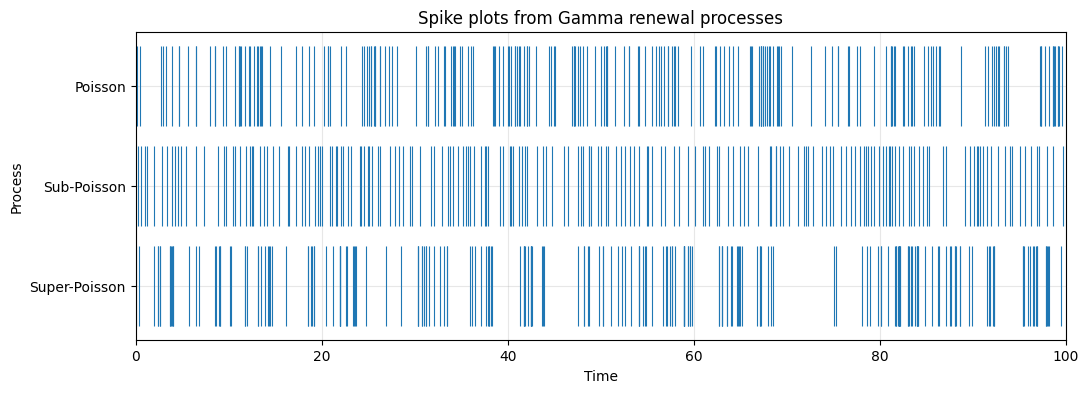

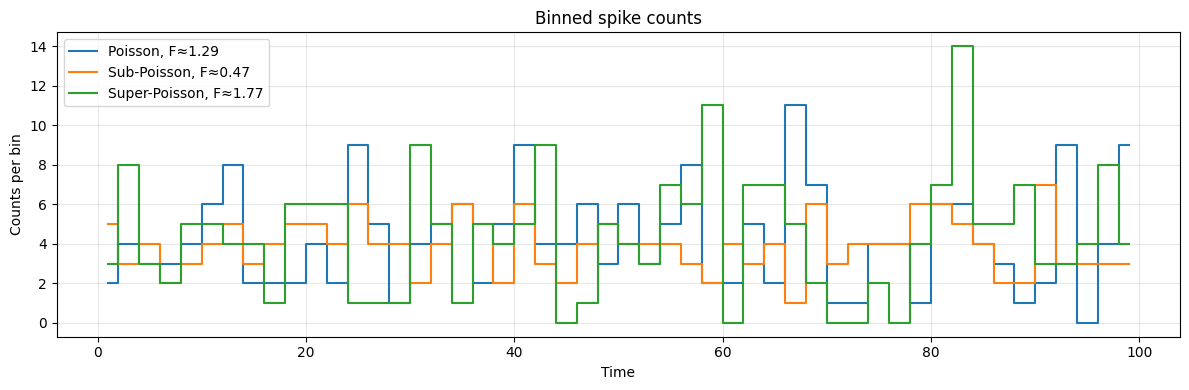

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def gamma_spike_train(Tmax, rate, k, rng=None):
    """
    Generate spike times from a Gamma renewal process.

    Parameters
    ----------
    Tmax : float
        Total observation time.
    rate : float
        Mean event rate, so mean waiting time = 1/rate.
    k : float
        Gamma shape parameter.
        k = 1   -> Poisson
        k > 1   -> sub-Poisson
        k < 1   -> super-Poisson
    rng : np.random.Generator or None
        Random number generator.

    Returns
    -------
    times : np.ndarray
        Sorted spike times in [0, Tmax).
    """
    if rng is None:
        rng = np.random.default_rng()

    # Choose scale theta so mean waiting time = k*theta = 1/rate
    theta = 1.0 / (rate * k)

    times = []
    t = 0.0
    while True:
        tau = rng.gamma(shape=k, scale=theta)
        t += tau
        if t >= Tmax:
            break
        times.append(t)

    return np.array(times)


def binned_counts(times, Tmax, nbins):
    """
    Bin spike times into equal-width time bins.
    """
    edges = np.linspace(0.0, Tmax, nbins + 1)
    counts, _ = np.histogram(times, bins=edges)
    return counts, edges


def fano_from_bins(times, Tmax, nbins=100):
    """
    Estimate Fano factor from counts in equal time bins.
    """
    counts, _ = binned_counts(times, Tmax, nbins)
    mean_counts = np.mean(counts)
    if mean_counts == 0:
        return np.nan
    return np.var(counts, ddof=1) / mean_counts


def spike_plot(ax, times, y, color=None, label=None):
    """
    Draw a raster/spike plot on a given axis.
    """
    ax.vlines(times, y - 0.4, y + 0.4, color=color, linewidth=0.8, label=label)


def main():
    rng = np.random.default_rng(12345)

    # Simulation parameters
    Tmax = 100.0
    rate = 2.0   # same mean rate for all three processes

    # Gamma shape parameters
    k_poisson = 1.0
    k_sub = 3.0
    k_super = 0.5

    # Generate spike times
    times_poisson = gamma_spike_train(Tmax, rate, k_poisson, rng=rng)
    times_sub = gamma_spike_train(Tmax, rate, k_sub, rng=rng)
    times_super = gamma_spike_train(Tmax, rate, k_super, rng=rng)

    # Estimate Fano factors from binned counts
    F_poisson = fano_from_bins(times_poisson, Tmax, nbins=100)
    F_sub = fano_from_bins(times_sub, Tmax, nbins=100)
    F_super = fano_from_bins(times_super, Tmax, nbins=100)

    # Print summary
    print("Estimated Fano factors from binned counts:")
    print(f"  Poisson      (k={k_poisson}): {F_poisson:.3f}")
    print(f"  Sub-Poisson  (k={k_sub})   : {F_sub:.3f}")
    print(f"  Super-Poisson(k={k_super}) : {F_super:.3f}")
    print()
    print("Theoretical long-time Fano factors:")
    print(f"  Poisson      : {1/k_poisson:.3f}")
    print(f"  Sub-Poisson  : {1/k_sub:.3f}")
    print(f"  Super-Poisson: {1/k_super:.3f}")

    # --------------------------
    # Figure 1: spike raster plot
    # --------------------------
    fig, ax = plt.subplots(figsize=(12, 4))

    spike_plot(ax, times_poisson, y=3, label=f"Poisson (k={k_poisson})")
    spike_plot(ax, times_sub, y=2, label=f"Sub-Poisson (k={k_sub})")
    spike_plot(ax, times_super, y=1, label=f"Super-Poisson (k={k_super})")

    ax.set_yticks([1, 2, 3])
    ax.set_yticklabels(["Super-Poisson", "Sub-Poisson", "Poisson"])
    ax.set_xlabel("Time")
    ax.set_ylabel("Process")
    ax.set_title("Spike plots from Gamma renewal processes")
    ax.set_xlim(0, Tmax)
    ax.grid(alpha=0.3)

    # --------------------------
    # Figure 2: binned counts
    # --------------------------
    nbins = 50
    counts_p, edges = binned_counts(times_poisson, Tmax, nbins)
    counts_s, _ = binned_counts(times_sub, Tmax, nbins)
    counts_sp, _ = binned_counts(times_super, Tmax, nbins)
    bin_centers = 0.5 * (edges[:-1] + edges[1:])

    fig2, ax2 = plt.subplots(figsize=(12, 4))
    ax2.step(bin_centers, counts_p, where="mid", label=f"Poisson, F≈{F_poisson:.2f}")
    ax2.step(bin_centers, counts_s, where="mid", label=f"Sub-Poisson, F≈{F_sub:.2f}")
    ax2.step(bin_centers, counts_sp, where="mid", label=f"Super-Poisson, F≈{F_super:.2f}")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Counts per bin")
    ax2.set_title("Binned spike counts")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()